# EJERCICIO 1

PUNTO 1

In [2]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("datasets/flete-aereo-vacunas-covid19-al-2021-06-28.xlsx", header=4)

#df.info()
#print(df.head(10))

df.rename(columns={old_name: new_name for old_name, new_name in 
zip(df.columns, [col.replace(' ', '') for col in df.columns])}, inplace=True)

#print(df.columns)

#Calculo la frecuencia de vuelos
frecuencia_vuelos = df['vuelo'].value_counts()
#print(frecuencia_vuelos)

#Calculo el porcentaje de cada vuelo
porcentaje_vuelos = (frecuencia_vuelos/df['vuelo'].count())
#print(round(porcentaje_vuelos * 100, 2))


C:\Users\fedew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


PUNTO 2

In [ ]:
#Vemos que tipo de datos tenemos en la columna vuelo
#print(df.vuelo.unique())

#Cuento los registros donde 'vuelo' es NaN (no contiene informacion). 
#(Cantidad Absurda, el df esta lleno de NaN al final, hay que limpiarlos)
registros_sin_vuelos = df['vuelo'].isna().sum()
print("antes de limpiar los NaN:", registros_sin_vuelos)

df.dropna(axis=0, thresh=3, inplace=True)
registros_sin_vuelos = df['vuelo'].isna().sum()
print("\ndespues de limpiar los NaN:", registros_sin_vuelos)

PUNTO 3

In [ ]:
print(df['factura_moneda_monto'].head(15))

#Hacer con REGEX. Repasar

PUNTO 4

In [ ]:
# Calculo la cantidad de vuelos que hay con origen en rusia y con origen en china. 
vuelos_china_rusia = len(df[(df['origen'] == 'Rusia')|(df['origen'] == 'China')])

# Calculo y muesto el porcentaje sobre el total de vuelos
print(f"El porcentaje de vuelos con origen desde Rusia y China es: {round(vuelos_china_rusia / len(df) * 100, 2)}%")

PUNTO 5

In [ ]:
# Utilizo las funciones maximo/minimo para mostrar cual fue el vuelo mas reciente/antiguo. 
print("Vuelo mas reciente: ", df['fecha_guía'].max())
print("Vuelo mas antiguo: ", df['fecha_guía'].min())

# Cantidad de dias entre vuelos, calculado solamente haciendo la diferencia entre lo que nos devuelven
# las funciones max/min
print("Cantidad de dias entre vuelos: ", max(df['fecha_guía']) - min(df['fecha_guía']))


PUNTO 6

In [ ]:
# Antes convertimos la columna 'vuelo' a tipo str
df['vuelo'] = df['vuelo'].astype(str)

# Escribimos el DataFrame en formato Parquet
df.to_parquet('vuelos_covid.parquet')               #me tira error


# Utilizando PyArrow

# Convertimos el DataFrame en una tabla de pyArrow
tabla = pa.Table.from_pandas(df)

# Escribimos el archivo Parquet
pq.write_table(tabla, 'datos.parquet')

# EJERCICIO 2

In [54]:
df_incendios = pd.read_csv("./datasets/incendios-cantidad-causas-provincia_2022.csv", encoding='latin-1', header=3)

#VISUALIZACION Y ADECUACION
df_incendios.head(15)
#df_incendios.info()
#df_incendios.isnull().sum()

df_incendios['natural'] = df_incendios['natural'].str.replace('-', '0')
df_incendios = df_incendios.rename(columns= {'anio' : 'año'})
df_incendios['provincia'] = df_incendios['provincia'].str.strip() #para corregir espacios al final y al principio
df_incendios['provincia'] = df_incendios['provincia'].replace({'Cordoba' : 'Córdoba'}) # para corregir dos provincias con mismo nombre

df_incendios['provincia'].sort_values().unique()
df_incendios.head(22)


,año,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0
3,1993,Chubut,21,18,0,0,3
4,1993,Córdoba,151,0,0,0,151
5,1993,Corrientes,48,0,0,0,48
6,1993,Entre Ríos,179,0,0,0,179
7,1993,Formosa,1,0,1,0,0
8,1993,Jujuy,0,0,0,0,0
9,1993,La Pampa,67,0,0,0,67


PUNTO 1

In [55]:
# OBTENGO LA CANTIDAD DE INCENCIOS POR AÑO PARA TODO EL PAIS 
# Y LUEGO OBTENGO EL AÑO CON MAYOR CANT DE INCENDIOS

cant_incendios_años = df_incendios.groupby('año')['total'].sum()

mayor_cantidad = cant_incendios_años.idxmax()

print(mayor_cantidad)

2008


PUNTO 2

In [60]:
# Primero filtro por la provincia de Cordoba y tambien 
# filtro por separado por el rango de años solicitados
filtro_años_cordoba = df_incendios[(df_incendios['año'].between(1993, 2021)) & (df_incendios['provincia'] == 'Córdoba')]

# Calculo la cantidad de incendios por año
incendios_cordoba_años = filtro_años_cordoba.groupby('año')['total'].sum()

print(incendios_cordoba_años)

año
1993     151
1994     161
1995    2441
1996      92
1997     387
1998     307
1999      55
2000     869
2001     194
2002     101
2003     119
2004     154
2006     438
2007     346
2008     157
2009     229
2011     147
2012     135
2013     173
2014     291
2019     273
2020     264
2021     198
Name: total, dtype: int64


PUNTO 3

In [ ]:
# Primero filtro el rando de años solicitados
filtro_años = df_incendios[df_incendios['año'].between(1993, 2021)]

# Segundo, agrupo por años los datos, luego solo trabajo con la columna 'intencional' y 
# extraigo cada indice del maximo de incencios en cada grupo de años.
indices_maximos = filtro_años.groupby('año')['intencional'].idxmax()

# Creo la tabla con .loc, al cual le paso los indices_maximos para que filtre el 
# df original, y las columnas de mi interes. Agrego tambien .reset_index para que arranque con el 
# indice 0 y no con el del df original
tabla_maximos = filtro_años.loc[indices_maximos, [ 'año', 'provincia', 'intencional']].reset_index(drop=True)

print(tabla_maximos)

     año         provincia  intencional
0   1993  Tierra del Fuego            2
1   1994         Río Negro            7
2   1995         Río Negro          250
3   1996         Catamarca         1662
4   1997         Río Negro          453
5   1998      Buenos Aires          583
6   1999             Chaco          503
7   2000             Chaco          549
8   2001             Chaco          284
9   2002      Buenos Aires          358
10  2003         Río Negro          790
11  2004          Santa Fe          290
12  2005           Córdoba          515
13  2006          Santa Fe          581
14  2007         Río Negro         1154
15  2008         Río Negro         1528
16  2009         Río Negro         1074
17  2010         Río Negro          988
18  2011          Santa Fe         1214
19  2012          Santa Fe         1472
20  2013          Santa Fe         1158
21  2014          Santa Fe          617
22  2015          Santa Fe          592
23  2016          Santa Fe          702


Punto 4

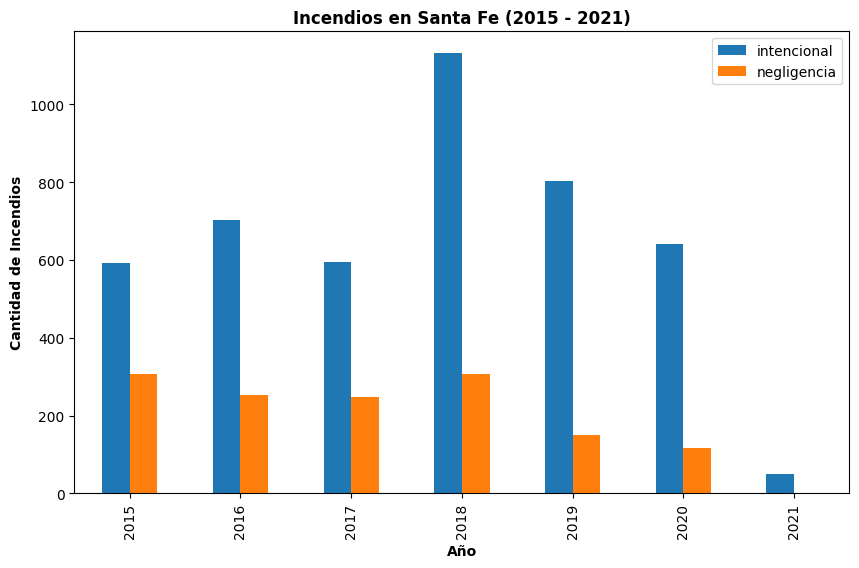

In [ ]:
# Primero filtro el dataset con el rango de años y la provincia de Santa Fe
filtro_años_sta_fe = df_incendios[(df_incendios['año'].between(2015, 2021)) & (df_incendios['provincia'] == 'Santa Fe')]

# Agrupo por años, trabajo solo con las columnas intencional, negligencia y natural, y sumo sus resultados
incendios_santa_fe = filtro_años_sta_fe.groupby('año')[['intencional', 'negligencia', 'natural']].sum()

# Creo el grafico con un tamaño de x=10, y=6
incendios_santa_fe.plot.bar(figsize=(10, 6))

# Le pongo un titulo y nombre a los ejes, con el detalle de que este en negrita.
plt.title("Incendios en Santa Fe (2015 - 2021)", fontweight="bold")
plt.xlabel("Año", fontweight="bold")
plt.ylabel("Cantidad de Incendios", fontweight="bold")
plt.show()

PUNTO 5

In [ ]:
# Primero filtro el dataset con el rango de años y la provincia de Rio Negro
filtro_años_rio_negro = df_incendios[(df_incendios['año'].between(1993, 2021)) & (df_incendios['provincia'] == 'Río Negro')]

# Corrijo columna natural que tenia formato str y no int
filtro_años_rio_negro['natural'] = filtro_años_rio_negro['natural'].astype(int)

# Calculo el promedio para las columnas intencional, natural y negligencia y redondeo los resultados a 2 decimales
promedio_tipo_incendio = round(filtro_años_rio_negro[['intencional', 'natural', 'negligencia']].mean(), 2)

promedio_tipo_incendio

intencional    343.76
natural         18.90
negligencia    240.97
dtype: float64

# EJERCICIO 10

In [3]:
dfventas = pd.read_excel("datasets/ventas.xlsx")
dfclientes = pd.read_excel("datasets/clientes_base.xlsx")

dfventas.head(20)

,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto
0,C1,Juana Perez,Apple Watch Series 8,2,399
1,C2,Roberto Gomezz,Nintendo Switch,1,299
2,C3,Carla Gonzáles Cuispe,Bose QuietComfort 45,1,329
3,C4,Jorge Martinez,Acer Predator Helios 300,1,1599
4,C5,Mariano Rodriguéz,iPad Pro,1,1099
5,C6,Roberto Gómez Acuña,HP Spectre x360,1,1399
6,C7,Maria Garcìa,MacBook Air,1,1249
7,C8,Carlos Gonzales,Samsung Galaxy S22,3,849
8,C9,Miguel Ánjel,Dell Alienware,1,1999
9,C10,María García,Amazon Echo Dot,3,49


In [4]:
#df2.info()
dfclientes.head(15)

,id_cliente,nombre_cliente,ciudad,email
0,1,Lucia Fernandez,Villa María,luciaf2@mail.com
1,2,Carlos Gómez,Mendoza,carlosgomez@mail.com
2,3,Andrés Pérez,Corrientes,andresp3@mail.com
3,4,Roberto Gómez,Rosario,rgomez@mail.com
4,5,Roberto Gómez Acuña,Corrientes,robgoac@mail.com
5,6,Juana Pérez,Salta,juanaperez@mail.com
6,7,Lucía Hernández,Santa Fe,luciahernandez@mail.com
7,8,Andrés Pérez Gollán,Mar del Plata,andresp@mail.com
8,9,Miguel Ángel,Neuquén,miguelangel@mail.com
9,10,Marcos Rupetti,Bariloche,marcosg@mail.com


PUNTO 1

In [5]:
ventas_ipad_mac = dfventas[dfventas['producto'].str.contains('iPad|MacBook')]

#print(ventas_ipad)
ventas_ipad_mac['monto'] = ventas_ipad_mac['precio_usd_producto'] * ventas_ipad_mac['cantidad']

monto_total = ventas_ipad_mac['monto'].sum()

print(monto_total)
ventas_ipad_mac

6663


,id_venta,nombre_cliente,producto,cantidad,precio_usd_producto,monto
4,C5,Mariano Rodriguéz,iPad Pro,1,1099,1099
6,C7,Maria Garcìa,MacBook Air,1,1249,1249
15,C16,Laura Martínez,iPad mini,1,559,559
18,C19,Andres Pérrez,MacBook Pro,1,1999,1999
22,C23,Andres Péres,iPad Air,2,599,1198
38,C39,Juan Perez,iPad mini,1,559,559


PUNTO 2

In [7]:
union = pd.merge(dfventas, dfclientes, on='nombre_cliente')

# Se nota que en el dataframe dfventas hay 42 entradas a diferencia del dataframe resultante 
# que tiene solo 14 entradas.

dfventas.info()
dfclientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id_venta             42 non-null     str  
 1   nombre_cliente       42 non-null     str  
 2   producto             42 non-null     str  
 3   cantidad             42 non-null     int64
 4   precio_usd_producto  42 non-null     int64
dtypes: int64(2), str(3)
memory usage: 3.1 KB
<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_cliente      36 non-null     int64
 1   nombre_cliente  36 non-null     str  
 2   ciudad          36 non-null     str  
 3   email           36 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.7 KB


PUNTO 3

In [8]:
porcentaje = round((union['nombre_cliente'].count() / dfclientes['nombre_cliente'].count()) * 100, 2)

print(porcentaje, "%")

38.89 %
